This notebook will create the basic "counting and types" figure which also will show the plot-type accuracy plots.

In [3]:
main_llm_dir = '/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/'

# low-tier
low_dirs_to_use = ['chatgpt_api/', 'gemini/', 'claude_haiku/']

# mid-to-high tier
#midHigh_dirs_to_use = ['chatgpt_api_highR_lowVerbose/', 'claude_haiku_thinking/', 'chatgpt_api_highR_lowVerbose_mini/']
midHigh_dirs_to_use = ['chatgpt_api_highR_lowVerbose/', 'claude_haiku_thinking_maxT8000/', 'chatgpt_api_highR_lowVerbose_mini/']


# full baseline data stored
dir_jsons = '/Users/jnaiman/Dropbox/jcdl_followup/synthetic_figures/qa_jsons/'

save_fig_dir = '/Users/jnaiman/Dropbox/jcdl_followup/paper_figures/'

replace_names = {'chatgpt_api':'ChatGPT', 
                        'chatgpt_api_highR_lowVerbose':'ChatGPT-HR',
                        #'chatgpt_api_highR_lowVerbose_mini':'ChatGPT-HR-mini', 
                        'chatgpt_api_highR_lowVerbose_mini':'ChatGPT-HRM', 
                        'gemini':'Gemini', 
                        'claude_haiku':'Claude', 
                        'claude_haiku_thinking':'Claude-T1',
                        'claude_haiku_thinking_maxT8000':'Claude-T'
                        }

In [101]:
from sys import path
path.append('../')

import matplotlib.pyplot as plt
from importlib import reload
from copy import deepcopy
import numpy as np
import pandas as pd
import seaborn as sns
import fastwer
import matplotlib.gridspec as gridspec


import utils.results_plotting_utils
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import create_output_marks

reload(utils.results_plotting_utils)
from utils.results_plotting_utils import add_kde_contours

dirs_to_use = deepcopy(low_dirs_to_use)
dirs_to_use.extend(midHigh_dirs_to_use)

In [31]:
def make_question_tags():
    df_question_tags = {}
    for t in ['tag', 'question', 'Level', 'Type']:
        df_question_tags[t] = []
    return df_question_tags



In [9]:
import utils.results_plotting_utils
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import get_dirs_names_files

dirnames, dirs, files_parsed = get_dirs_names_files(main_llm_dir, 
        dirs_to_use, 
        replace_names = replace_names,
        verbose=True)

DIRS:
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_sonnet_maxtoken8000
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/gemini
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_mini
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_sonnet
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku_thinking
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_old
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_highR_lowVerbose
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku_thinking_maxT8000
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_highR_lowVerbose_mini

ONLY USED DIRNAMES, DIRS
ChatGPT ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api/
Gemini ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/gemini/
Claude ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_h

In [10]:
import utils.parse_lmm_output_utils
reload(utils.parse_lmm_output_utils)

from utils.parse_lmm_output_utils import parse_json_files, fix_aspect

df = parse_json_files(dirnames, dirs, files_parsed, dir_jsons, 
                     verbose=False, use_explanation=True)
print("!!!!!!!! DONE LOADING !!!!!!!!!!!")

[ERROR]: different types of values, could not fix:
  GT: 14809.219467762321 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: -58.959594910670056 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: -58.73660626981654 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"median y": ""}

[ERROR]: different types of values, could not fix:
  GT: 263476.232548973 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 52.99653059346398 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 4.181899993866321 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: -60.00537889895291 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[E

<unknown>:1: SyntaxWarning: invalid escape sequence '\c'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\m'


[ERROR]: different types of values, could not fix:
  GT: -61.790358773008236 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: -66.39066830315112 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: -65.59246321206226 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"median color": ""}

[ERROR]: different types of values, could not fix:
  GT: -6.975695803294384 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"median color": ""}

[ERROR]: different types of values, could not fix:
  GT: 1228.6434162396638 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 213328.4338576842 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 3.102021238091375 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"medi

<unknown>:1: SyntaxWarning: invalid escape sequence '\!'
<unknown>:1: SyntaxWarning: invalid escape sequence '\!'
<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\_'


[ERROR]: different types of values, could not fix:
  GT: -34.081931631282536 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 17520347215890.066 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 4361323308289.718 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 46011.12787325964 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: -103166.10457483416 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 89.100044196083 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: 116.44542286828813 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]:

<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: invalid escape sequence '\D'
<unknown>:1: SyntaxWarning: invalid escape sequence '\P'
<unknown>:1: SyntaxWarning: invalid escape sequence '\o'
<unknown>:2: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1: SyntaxWarning: invalid escape sequence '\p'
<unknown>:1: SyntaxWarning: invalid escape sequence '\g'
<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: invalid escape sequence '\e'
<unknown>:1: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1: SyntaxWarning: inv

[ERROR]: different types of values, could not fix:
  GT: 130.54067743578003 <class 'float'>
  LLM: Unable to determine <class 'str'>
  raw LLM: {"mean color": "Unable to determine"}

[ERROR]: different types of values, could not fix:
  GT: -249349.01704986204 <class 'float'>
  LLM: Unable to determine from visible labels <class 'str'>
  raw LLM: {"maximum color": "Unable to determine from visible labels"}

[ERROR]: different types of values, could not fix:
  GT: -513215.2147431419 <class 'float'>
  LLM: null <class 'str'>
  raw LLM: {"mean color": "null"}

[ERROR]: different types of values, could not fix:
  GT: -857456.5832552586 <class 'float'>
  LLM: Unable to determine from image <class 'str'>
  raw LLM: {"minimum color": "Unable to determine from image"}



<unknown>:3: SyntaxWarning: invalid escape sequence '\o'
<unknown>:2: SyntaxWarning: invalid escape sequence '\o'


!!!!!!!! DONE LOADING !!!!!!!!!!!


In [11]:
df.head()

,image id,plot number,plot type,question,use list,model,model id,LMM Answer,GT Answer,Level,Level Type,Explanation
0,Picture_000140_qa,NaN,None,How many panels are in this figure?,False,ChatGPT,gpt-5.4-nano-2026-03-17,"{'nrows': 2, 'ncols': 1}","{'nrows': 1, 'ncols': 1}",Level 1,Figure-level questions,{'explanation': 'The figure is composed of two...
1,Picture_000140_qa,NaN,None,What is the plot style used in this figure?,False,ChatGPT,gpt-5.4-nano-2026-03-17,{'plot style': 'classic'},{'plot style': 'seaborn-v0_8-muted'},Level 1,Figure-level questions,{'explanation': 'The figure uses Matplotlib’s ...
2,Picture_000140_qa,NaN,None,What is the colormap that was used in this fig...,False,ChatGPT,gpt-5.4-nano-2026-03-17,{'colormap': 'RdPu'},{'colormap': 'RdPu_r'},Level 1,Figure-level questions,{'explanation': 'The plot’s colors are predomi...
3,Picture_000140_qa,NaN,None,What is the aspect ratio of this figure?,False,ChatGPT,gpt-5.4-nano-2026-03-17,{'aspect ratio': 0.5625},{'aspect ratio': 0.7519706245704967},Level 1,Figure-level questions,{'explanation': 'The image shows a portrait-or...
4,Picture_000140_qa,NaN,None,What are the titles for each figure panel?,False,ChatGPT,gpt-5.4-nano-2026-03-17,{'titles': ['']},{'titles': ['']},Level 1,Figure-level questions,{'explanation': 'The image shows a single plot...


In [ ]:
questions_figure = [
    {'tag':'# panels', 'question':'How many panels are in this figure?', 'type':'special'}, # have to calculate this from answer
    {'tag':'titles', 'question': 'What are the titles for each figure panel?', 'type':'string list', 'use cer':True, 'use bar':True},
    {'tag':'x-labels', 'question': 'What are the x-axis titles for each figure panel?', 'type':'string list', 'use cer':True, 'use bar':True},
    {'tag':'y-labels', 'question': 'What are the y-axis titles for each figure panel?', 'type':'string list', 'use cer':True, 'use bar':True},
]



In [18]:
reload(utils.results_plotting_utils)
reload(utils.parse_lmm_output_utils)
from utils.parse_lmm_output_utils import get_lmm_gt
from utils.results_plotting_utils import calculate_plot_accuracies

qtags = make_question_tags()
_, dfplot1 = calculate_plot_accuracies(df,questions_figure, qtags)

In [21]:
# only those that have at least 2 instances
count_cut = 2

dfpsort = dfplot1['# panels GT'].value_counts().sort_index()
# dfpsort
panels_cut = dfpsort[dfpsort >= count_cut].index
print('only these panels:', np.array(panels_cut.values))

dfcut = dfplot1.copy()#[dfplot[dfplot['# panels GT']] >= panels_cut.max()]
dfcut = dfcut[dfcut['# panels GT'].isin(panels_cut)]
dfcut.head()

only these panels: [ 1  2  3  4  5  6  8  9 12 15]


,Tag,# panels GT,ChatGPT # panels,Gemini # panels,Claude # panels,ChatGPT-HR # panels,Claude-T # panels,ChatGPT-HRM # panels,ChatGPT titles,Gemini titles,...,Claude x-labels,ChatGPT-HR x-labels,Claude-T x-labels,ChatGPT-HRM x-labels,ChatGPT y-labels,Gemini y-labels,Claude y-labels,ChatGPT-HR y-labels,Claude-T y-labels,ChatGPT-HRM y-labels
0,# panels,1,2,2,2,2,1,2,1.000000,1.000000,...,0.952381,0.952381,0.952381,0.952381,-0.054054,0.783784,0.486486,0.378378,0.459459,0.783784
1,# panels,5,6,5,5,5,5,5,0.000000,1.000000,...,0.696970,0.535354,0.767677,0.787879,0.152778,0.833333,0.527778,0.458333,0.500000,0.763889
2,# panels,1,1,1,1,1,1,1,0.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.317460,0.587302,0.555556,0.492063,0.523810,0.507937
3,# panels,8,8,8,12,8,8,8,0.088235,0.521739,...,0.835616,0.726027,0.561644,0.849315,0.530000,0.560000,0.040000,0.580000,0.147287,0.810000
4,# panels,9,9,9,9,9,9,9,0.474747,0.606780,...,0.311881,0.466667,0.308333,0.758333,0.620155,0.612403,0.255814,0.705426,0.279070,0.844961


In [26]:
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import create_output_marks, add_kde_contours, make_square_grid_figure_gs

marker_sizes, marker_styles, colors, labels = create_output_marks(df, marker_min=20, marker_max=70)

In [64]:
def get_cer(dfsub2,df):
    lmm = []
    npanels = []
    for i,r in dfsub2.iterrows():
        g = list(r['GT Answer'].values())[0]
        l = list(r['LMM Answer'].values())[0]
        if isinstance(l,float):
            if pd.isnull(l): # just an nan
                print(l)
                l = [""]*len(g)
        if not isinstance(g,list) or not isinstance(l,list):
            print('g:', g)
            print('l:', l)
            import sys; sys.exit()
        # otherwise, collapse into single strings
        #gs = " ".join(g); ls = " ".join(l)
        gs = "".join(g); ls = "".join(l)
        if len(gs) == 0:
            if len(ls) == 0:
                cer = 0.0
            else:
                cer = len(ls)
        elif len(ls) == 0:
            if len(gs) == 0:
                cer = 0.0
            else:
                cer = len(gs)
        else:
            cer = fastwer.score([ls], [gs], char_level=True)
        lmm.append(cer)
        imageid = r['image id']
        nr = df[(df['image id']==imageid)&(df['question']=='How many panels are in this figure?')]['GT Answer'].values[0]
        npanel = nr['nrows']*nr['ncols']
        npanels.append(npanel)
    return npanels, lmm

nan


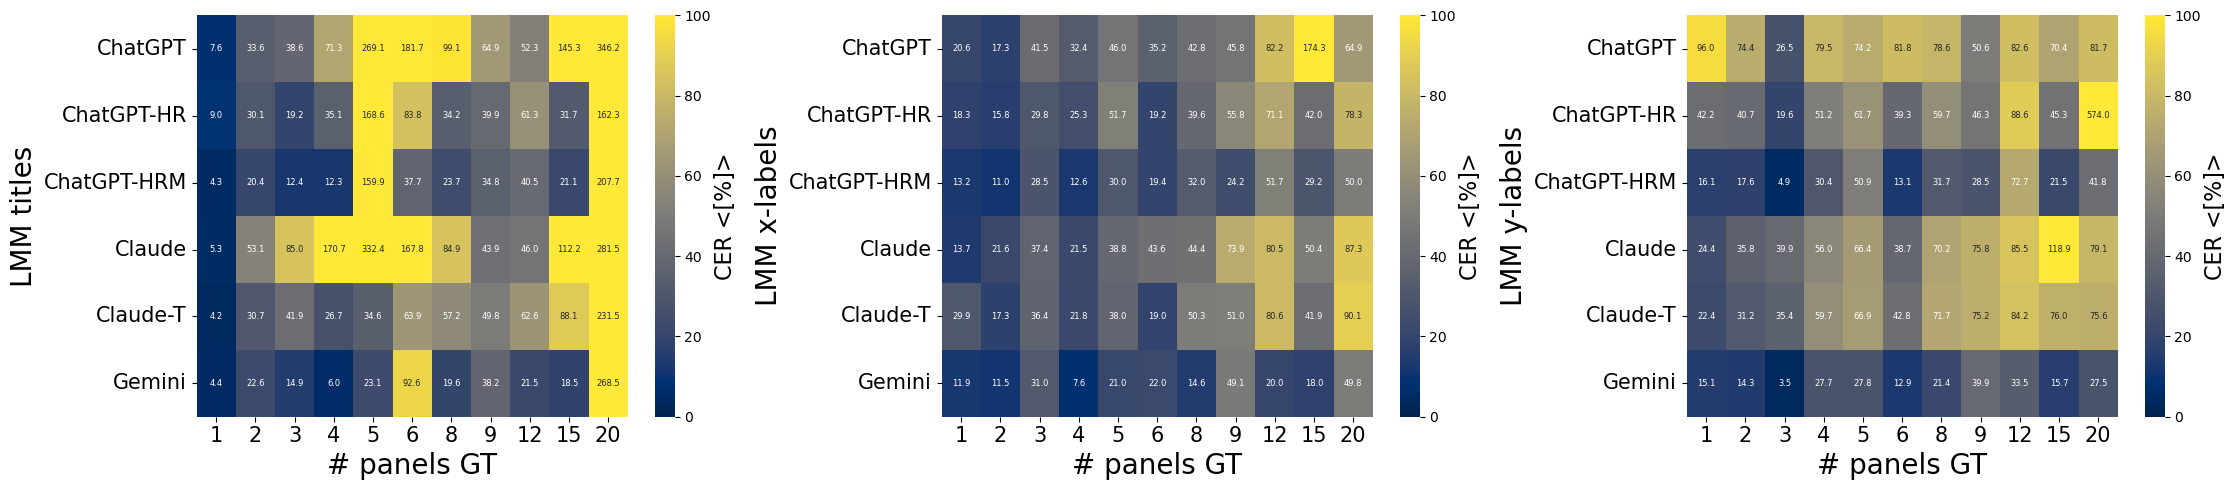

In [65]:
fixed_axis = '# panels GT'

base = 5
#nx = 1; ny = 3
#npanels = nx*ny
#fig, axes = plt.subplots(1,npanels, figsize=(base*npanels,base))
levels = [0.25, 0.5, 0.75]

fontsize = 20
tick_fontsize = 15
legend_fontsize = 18
barfontsize = 16
barpad = 2
cmap = 'cividis'

eq_linethick = 3
eq_linestyle = '--'
eq_linecolor = 'gray'

plot_kde = True

# for plotting
dfplot = dfcut.copy()

fudge = 2

iqset = 0
plot_diffs = False
normalize_diff = False

questions_plot = questions_figure[1:] # skip first panel

specials = ['aspect ratio']
use_average_percent = True


#fig, axes = make_square_grid_figure_gs(len(questions_plot), figsize_per_plot=(base,base))
fac = 1.5
fig, axes = plt.subplots(1,len(questions_plot), figsize=(base*len(questions_plot)*fac, base))
counts_df = {}

for iq,q in enumerate(questions_plot):
    dfsub = df[df['question']==q['question']]
    counts_df[q['tag']] = {'use bar':False, 'df':{}, 'panel':-1}

    for imodel, model in enumerate(dfsub['model'].unique()):
        dfsub2 = dfsub[dfsub['model']==model]
        #gttag = '# panels GT' # for fixed axis
        if fixed_axis is not None:
            gttag = fixed_axis
        lmtag = labels[model] + ' ' + q['tag'] 
        if 'yfudge' not in q:
            q = deepcopy(q)
            q['yfudge'] = fudge
        if 'xfudge' not in q:
            q['xfudge'] = fudge
        gt = dfplot[gttag]
        lmm = dfplot[lmtag]

        if 'use cer' in q:
            #print('use cer')
            #import sys; sys.exit()
            gt, lmm = get_cer(dfsub2,df)
            #print(len(gt), len(lmm))

        ylabel_tag = 'LMM ' + q['tag']

        useBar = False
        if 'string' in q['type']: # convert to %
            if 'use cer' not in q:
                lmm *= 100
            if not use_average_percent:
                ylabel_tag += ' [%]'
            else:
                #print('yo', q['tag'])
                ylabel_tag += ' <[%]>'
                if 'use cer' not in q:
                    lmm = dfplot.groupby(gttag)[lmtag].mean().reset_index()[lmtag]
                    gt = dfplot.groupby(gttag)[lmtag].mean().reset_index()[gttag]
                else:
                    dfplott = pd.DataFrame({gttag:gt, lmtag:lmm})
                    finite_mask = (np.isfinite(dfplott[lmtag])) & ~pd.isnull(dfplott[lmtag])
                    #result = df[finite_mask]
                    lmm = dfplott[finite_mask].groupby(gttag)[lmtag].mean().reset_index()[lmtag]
                    gt = dfplott[finite_mask].groupby(gttag)[lmtag].mean().reset_index()[gttag]
                if 'use bar' in q:
                    if q['use bar']:
                        acctag = 'Accuracy <[%]>'
                        if 'use cer' in q:
                            acctag = 'CER <[%]>'
                        counts_df[q['tag']]['use bar'] = True
                        counts_df[q['tag']]['panel'] = iq
                        useBar = True
                        # print('Double check this calculation!')
                        # import sys; sys.exit()
                        for cname in ['Model', gttag, acctag]:
                            if cname not in counts_df[q['tag']]['df']:
                                counts_df[q['tag']]['df'][cname] = []
                        counts_df[q['tag']]['df']['Model'].extend(np.repeat(model,len(gt)))
                        counts_df[q['tag']]['df'][gttag].extend(deepcopy(gt))
                        counts_df[q['tag']]['df'][acctag].extend(deepcopy(lmm))
                        counts_df[q['tag']]['accuracy tag'] = acctag

        if useBar:
            continue
                
        # if iq == iqset:
        #     add_kde_contours(axes[iq], gt, lmm, colors[model], 
        #                         labels[model], marker_styles[model], marker_sizes[model], 
        #                         levels=levels, plot_kde=plot_kde)
        # else:
        # add_kde_contours(axes[iq], gt, lmm, colors[model], 
        #                         None, marker_styles[model], marker_sizes[model], 
        #                         levels=levels, plot_kde=plot_kde)
    # axes[iq].set_xlabel(gttag, fontsize=fontsize)
    # axes[iq].set_ylabel(ylabel_tag, fontsize=fontsize)

    # if not plot_diffs and q['tag'] not in specials and 'string' not in q['type']:
    #     axes[iq].plot([np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
    #                     [np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
    #                     linestyle=eq_linestyle, linewidth=eq_linethick, zorder=10, 
    #                     color=eq_linecolor)
    #     axes[iq].set_ylabel(ylabel_tag, fontsize=fontsize)
    #     if 'string' not in q['type'] and q['tag'] not in specials:
    #         axes[iq].set_ylim(np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge'])
    #     else:
    #         axes[iq].set_ylim(np.min(lmm)-q['yfudge'], np.max(lmm)+q['yfudge'])
    #     axes[iq].set_xlim(np.min(gt)-q['xfudge'], np.max(gt)+q['xfudge'])

    # # for percentages
    # if 'string' in q['type']:
    #     axes[iq].set_ylim(0-q['yfudge'], 100+q['yfudge'])

    #axes[iqset].legend()

# go back and plot all models-things
for k,d in counts_df.items():
    if d['use bar']:
        acctag = d['accuracy tag']
        dfc = pd.DataFrame(d['df'])
        cgt = dfc.columns[~dfc.columns.isin(['Model',acctag])][0]
        pivot = dfc.pivot(index='Model', columns=cgt, values=acctag)
        cmapadder = ''
        # if 'CER' in acctag:
        #     cmapadder = '_r'
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap+cmapadder, vmin=0, vmax=100, ax=axes[d['panel']], annot_kws={'size': 6})
        axes[d['panel']].set_ylabel('LMM '+k, fontsize=fontsize)
        axes[d['panel']].set_xlabel(gttag, fontsize=fontsize)
        cbar = axes[d['panel']].collections[0].colorbar
        cbar.set_label(acctag, fontsize=barfontsize, labelpad=barpad)


# set font sizes
for ax in axes:
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    # legend = ax.get_legend()
    # if legend is not None:
    #     # Set legend font size for second subplot
    #     ax.legend(fontsize=legend_fontsize)

fig.tight_layout()
fig.savefig(save_fig_dir + 'titles_cer.pdf')

Here are the params used for generating figures:

```python
###### TITLE & X/Y LABELS #######
title_params = {'prob':0.5, 'n words':{'min':1, 'max':5},
               'capitalize':{'none':0.1, 'first':0.5, 'all':0.7}, # none is all lower case, first just capitalizes first word, all is all uppercase
                'equation':{'prob':0.1}, # probability that any one word will be an equation (~0.25)
               }
colorbar_params = {'prob':0.5, 'n words':{'min':1, 'max':3},
               'capitalize':{'none':0.1, 'first':0.5, 'all':0.7}, # none is all lower case, first just capitalizes first word, all is all uppercase
                'equation':{'prob':0.1}, # probability that any one word will be an equation (~0.25)
                }
xlabel_params = {'prob':0.90, 'n words':{'min':1, 'max':3},
                'capitalize':{'none':0.1, 'first':0.5, 'all':0.7}, # none is all lower case, first just capitalizes first word, all is all uppercase
                'equation':{'prob':0.25}, # probability that any one word will be an equation (~0.25)
                }
ylabel_params = {'prob':0.90, 'n words':{'min':1, 'max':3},                 
                 'capitalize':{'none':0.1, 'first':0.5, 'all':0.7}, # none is all lower case, first just capitalizes first word, all is all uppercase
                'equation':{'prob':0.25}, # probability that any one word will be an equation
                }
```

## Also, try CER per title/label

In [72]:
from utils.parse_lmm_output_utils import map_lg_lt

In [75]:
def get_cer_per(dfsub2,df):
    lmm = []
    npanels = []
    for i,r in dfsub2.iterrows():
        g = list(r['GT Answer'].values())[0]
        l = list(r['LMM Answer'].values())[0]
        if isinstance(l,float):
            if pd.isnull(l): # just an nan
                print(l)
                l = [""]*len(g)
        if not isinstance(g,list) or not isinstance(l,list):
            print('g:', g)
            print('l:', l)
            import sys; sys.exit()

        # are they the same length?
        if len(g) != len(l):
            l,g = map_lg_lt(l,g,verbose=False)

        for gs,ls in zip(g,l):
            if len(gs) == 0:
                if len(ls) == 0:
                    cer = 0.0
                else:
                    cer = len(ls)
            elif len(ls) == 0:
                if len(gs) == 0:
                    cer = 0.0
                else:
                    cer = len(gs)
            else:
                cer = fastwer.score([ls], [gs], char_level=True)
            lmm.append(cer)
            imageid = r['image id']
            nr = df[(df['image id']==imageid)&(df['question']=='How many panels are in this figure?')]['GT Answer'].values[0]
            npanel = nr['nrows']*nr['ncols']
            npanels.append(npanel)
    return npanels, lmm

In [89]:
dirs_to_use

['chatgpt_api/',
 'gemini/',
 'claude_haiku/',
 'chatgpt_api_highR_lowVerbose/',
 'claude_haiku_thinking_maxT8000/',
 'chatgpt_api_highR_lowVerbose_mini/']

In [91]:
# create model order
model_order = []  # adjust to your model names
for d in dirs_to_use:
    model_order.append(replace_names[d.replace('/','')])
model_order

['ChatGPT', 'Gemini', 'Claude', 'ChatGPT-HR', 'Claude-T', 'ChatGPT-HRM']

nan


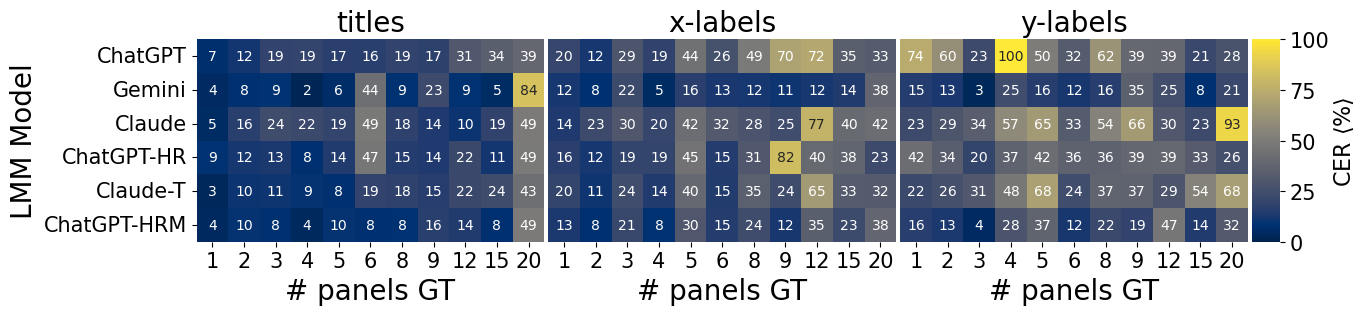

In [104]:
fixed_axis = '# panels GT'

base = 3

fontsize = 20
tick_fontsize = 15
legend_fontsize = 18
barfontsize = 16
cbar_tick_fontsize = 15
annot_fontsize = 10
#annot_fmt = '.1f'
annot_fmt = '.0f' # whole numbers

barpad = 2
cmap = 'cividis'

eq_linethick = 3
eq_linestyle = '--'
eq_linecolor = 'gray'

plot_kde = True

# for plotting
dfplot = dfcut.copy()

fudge = 2

iqset = 0
plot_diffs = False
normalize_diff = False

questions_plot = questions_figure[1:] # skip first panel

specials = ['aspect ratio']
use_average_percent = True

# memory
try:
    plt.close(fig)
except:
    pass

fac = 1.5
#fig, axes = plt.subplots(1,len(questions_plot), figsize=(base*len(questions_plot)*fac, base))


n_plots = len(questions_plot)

# add an extra narrow column for the colorbar
# fig = plt.figure(figsize=(base*n_plots*fac, base))
# gs = gridspec.GridSpec(1, n_plots + 1, 
#                        width_ratios=[1]*n_plots + [0.08],  # narrow last col for cbar
#                        wspace=0.3)
fig = plt.figure(figsize=(base*n_plots*fac, base), layout='constrained')
gs = gridspec.GridSpec(1, n_plots + 1,
                       width_ratios=[1]*n_plots + [0.08],
                       figure=fig)  # bind GridSpec to figure for constrained_layout
# update axis
axes = [fig.add_subplot(gs[0, i]) for i in range(n_plots)]
cbar_ax = fig.add_subplot(gs[0, n_plots])  # dedicated colorbar axis

counts_df = {}

for iq,q in enumerate(questions_plot):
    dfsub = df[df['question']==q['question']]
    counts_df[q['tag']] = {'use bar':False, 'df':{}, 'panel':-1}

    for imodel, model in enumerate(dfsub['model'].unique()):
        dfsub2 = dfsub[dfsub['model']==model]
        if fixed_axis is not None:
            gttag = fixed_axis
        lmtag = labels[model] + ' ' + q['tag'] 
        if 'yfudge' not in q:
            q = deepcopy(q)
            q['yfudge'] = fudge
        if 'xfudge' not in q:
            q['xfudge'] = fudge
        gt = dfplot[gttag]
        lmm = dfplot[lmtag]

        if 'use cer' in q:
            gt, lmm = get_cer_per(dfsub2,df)

        ylabel_tag = 'LMM ' + q['tag']

        useBar = False
        if 'string' in q['type']: # convert to %
            if 'use cer' not in q:
                lmm *= 100
            if not use_average_percent:
                ylabel_tag += ' [%]'
            else:
                #print('yo', q['tag'])
                ylabel_tag += ' <[%]>'
                if 'use cer' not in q:
                    lmm = dfplot.groupby(gttag)[lmtag].mean().reset_index()[lmtag]
                    gt = dfplot.groupby(gttag)[lmtag].mean().reset_index()[gttag]
                else:
                    dfplott = pd.DataFrame({gttag:gt, lmtag:lmm})
                    finite_mask = (np.isfinite(dfplott[lmtag])) & ~pd.isnull(dfplott[lmtag])
                    #result = df[finite_mask]
                    lmm = dfplott[finite_mask].groupby(gttag)[lmtag].mean().reset_index()[lmtag]
                    gt = dfplott[finite_mask].groupby(gttag)[lmtag].mean().reset_index()[gttag]
                if 'use bar' in q:
                    if q['use bar']:
                        acctag = 'Accuracy <[%]>'
                        if 'use cer' in q:
                            acctag = r'CER $\mathrm{\langle \% \rangle}$' #CER <[%]>'
                        counts_df[q['tag']]['use bar'] = True
                        counts_df[q['tag']]['panel'] = iq
                        useBar = True
                        # print('Double check this calculation!')
                        # import sys; sys.exit()
                        for cname in ['Model', gttag, acctag]:
                            if cname not in counts_df[q['tag']]['df']:
                                counts_df[q['tag']]['df'][cname] = []
                        counts_df[q['tag']]['df']['Model'].extend(np.repeat(model,len(gt)))
                        counts_df[q['tag']]['df'][gttag].extend(deepcopy(gt))
                        counts_df[q['tag']]['df'][acctag].extend(deepcopy(lmm))
                        counts_df[q['tag']]['accuracy tag'] = acctag

        if useBar:
            continue
                
# # go back and plot all models-things
# for k,d in counts_df.items():
#     if d['use bar']:
#         acctag = d['accuracy tag']
#         dfc = pd.DataFrame(d['df'])
#         cgt = dfc.columns[~dfc.columns.isin(['Model',acctag])][0]
#         pivot = dfc.pivot(index='Model', columns=cgt, values=acctag)
#         cmapadder = ''
#         # if 'CER' in acctag:
#         #     cmapadder = '_r'
#         sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap+cmapadder, vmin=0, vmax=100, ax=axes[d['panel']], annot_kws={'size': 6})
#         #axes[d['panel']].set_ylabel('LMM '+k, fontsize=fontsize)
#         axes[d['panel']].set_title('LMM '+k, fontsize=fontsize)
#         axes[d['panel']].set_xlabel(gttag, fontsize=fontsize)
#         cbar = axes[d['panel']].collections[0].colorbar
#         cbar.set_label(acctag, fontsize=barfontsize, labelpad=barpad)

for k,d in counts_df.items():
    if d['use bar']:
        acctag = d['accuracy tag']
        dfc = pd.DataFrame(d['df'])
        cgt = dfc.columns[~dfc.columns.isin(['Model',acctag])][0]
        pivot = dfc.pivot(index='Model', columns=cgt, values=acctag)
        pivot = pivot.reindex(model_order)
        cmapadder = ''
        
        is_leftmost = d['panel'] == 0
        is_rightmost = d['panel'] == len(counts_df) - 1
        
        # sns.heatmap(pivot, annot=True, fmt=annot_fmt, cmap=cmap+cmapadder, vmin=0, vmax=100,
        #             ax=axes[d['panel']], annot_kws={'size': annot_fontsize},
        #             cbar=is_rightmost,                        # (3) colorbar only on rightmost
        #             yticklabels=is_leftmost)                  # (2) y-tick labels only on leftmost
        sns.heatmap(pivot, annot=True, fmt=annot_fmt, cmap=cmap+cmapadder, vmin=0, vmax=100,
                    ax=axes[d['panel']], annot_kws={'size': annot_fontsize},
                    cbar=is_rightmost,
                    cbar_ax=cbar_ax if is_rightmost else None,
                    yticklabels=is_leftmost)

        # (1) move y-axis label to title, append existing title
        axes[d['panel']].set_title(k, fontsize=fontsize)
        axes[d['panel']].set_ylabel('')                       # remove "Model" y-axis label
        axes[d['panel']].set_xlabel(gttag, fontsize=fontsize)
        if d['panel'] == 0:
            axes[d['panel']].set_ylabel('LMM Model', fontsize=fontsize)
        
        # (3) colorbar label only on rightmost
        # if is_rightmost:
        #     cbar = axes[d['panel']].collections[0].colorbar
        #     cbar.set_label(acctag, fontsize=barfontsize, labelpad=barpad)
        #     cbar.ax.tick_params(labelsize=cbar_tick_fontsize)
        if is_rightmost:
            cbar_ax.set_ylabel(acctag, fontsize=barfontsize, labelpad=barpad)
            cbar_ax.tick_params(labelsize=cbar_tick_fontsize)

# set font sizes
for ax in axes:
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)


# fig.tight_layout()
fig.get_layout_engine().set(w_pad=0.02, h_pad=0.02, hspace=0, wspace=0)
fig.savefig(save_fig_dir + 'titles_cer_per.pdf')